In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from common.utils import pipeline
from common.ETL import save_mart

### Общие ETL шаги (подробнее в 01_.ipynb)

In [2]:
tables = {
    "well_telemetry": {
        "date_column": "timestamp"
    },

    "well_targets": {
        "date_column": "date"
    },

    "production": {
        "date_column": "date"
    }
}

results = []

for key in tables.keys():
    results.append(pipeline(table_name=key, date_column=tables[key]["date_column"]))

df_telemetry = results[0].copy()
df_targets = results[1].copy()
df_production = results[2].copy()

### Агрегация telemetry

In [3]:
telemetry_daily = (
    df_telemetry
    .groupby(["well_id", "date"], as_index=False)
    .agg(
        telemetry_avg_pressure_in=("pressure_in", "mean"),
        telemetry_avg_pressure_out=("pressure_out", "mean"),
        telemetry_avg_temperature=("temperature", "mean"),
        telemetry_work_hours=("pump_speed_rpm", lambda values: (values > 0).sum()),
    )
)

telemetry_daily["telemetry_avg_pressure"] = telemetry_daily[["telemetry_avg_pressure_in", "telemetry_avg_pressure_out"]].mean(axis=1)

### Агрегация production

In [4]:
production_daily = (
    df_production
    .groupby(["well_id", "date"], as_index=False)
    .agg(
        prod_avg_pressure=("pressure", "mean"),
        prod_avg_temperature=("temperature", "mean"),
        energy_kwh=("energy_kwh", "sum"),
        downtime_hours=("downtime_hours", "sum"),
    )
)

production_daily["power_kw"] = production_daily["energy_kwh"] / 24
production_daily["prod_work_hours"] = (24 - production_daily["downtime_hours"]).clip(lower=0, upper=24)

### Создание dataset

In [5]:
ml_dataset = (
    df_targets[["well_id", "date", "daily_oil_ton"]]
    .merge(production_daily, on=["well_id", "date"], how="left")
    .merge(telemetry_daily, on=["well_id", "date"], how="left")
)

ml_dataset["avg_pressure"] = ml_dataset["telemetry_avg_pressure"].combine_first(ml_dataset["prod_avg_pressure"])
ml_dataset["avg_temperature"] = ml_dataset["telemetry_avg_temperature"].combine_first(ml_dataset["prod_avg_temperature"])
ml_dataset["pump_work_hours"] = ml_dataset["telemetry_work_hours"].combine_first(ml_dataset["prod_work_hours"])

feature_columns = ["avg_pressure", "avg_temperature", "power_kw", "pump_work_hours"]
target_column = "daily_oil_ton"

ml_dataset = ml_dataset[["well_id", "date", target_column] + feature_columns].dropna()
ml_dataset.head()

,well_id,date,daily_oil_ton,avg_pressure,avg_temperature,power_kw,pump_work_hours
0,1,2025-10-01,212.4,108.652083,88.2875,310.416667,24.0
1,2,2025-10-01,185.9,103.402083,84.3500,283.333333,24.0
2,5,2025-10-01,197.2,118.800000,86.5000,300.000000,23.6
3,1,2025-10-02,213.8,121.000000,87.8000,312.083333,23.7
4,2,2025-10-02,184.8,114.800000,84.3000,281.875000,23.0


### Подготовка к обучение (выбор моделей + разделение на train/test)

In [6]:
unique_dates = sorted(ml_dataset["date"].unique())
test_days_count = max(1, int(len(unique_dates) * 0.2))
test_dates = unique_dates[-test_days_count:]

train_df = ml_dataset[~ml_dataset["date"].isin(test_dates)].copy()
test_df = ml_dataset[ml_dataset["date"].isin(test_dates)].copy()

X_train = train_df[feature_columns]
y_train = train_df[target_column]
X_test = test_df[feature_columns]
y_test = test_df[target_column]

models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
}

### Обучение модели

In [7]:
metrics = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    metrics.append({
        "model_name": model_name,
        "mae": mean_absolute_error(y_test, predictions),
        "rmse": np.sqrt(mean_squared_error(y_test, predictions)),
    })
    trained_models[model_name] = model

### Сравнение результатов

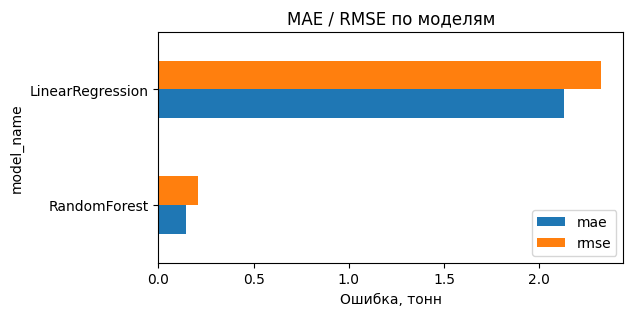

In [8]:
ml_metrics = pd.DataFrame(metrics).sort_values("rmse").reset_index(drop=True)
best_model_name = ml_metrics.loc[0, "model_name"]
best_model = trained_models[best_model_name]

ml_metrics.set_index("model_name")[["mae", "rmse"]].plot(kind="barh", figsize=(6, 3))
plt.title("MAE / RMSE по моделям")
plt.xlabel("Ошибка, тонн")
plt.show()

### Прогноз модели

In [9]:
mart_ml_predictions = test_df[["well_id", "date", target_column]].copy()
mart_ml_predictions["model_name"] = best_model_name
mart_ml_predictions["predicted_daily_oil_ton"] = best_model.predict(X_test)
mart_ml_predictions["prediction_error"] = mart_ml_predictions[target_column] - mart_ml_predictions["predicted_daily_oil_ton"]
mart_ml_predictions["abs_prediction_error"] = mart_ml_predictions["prediction_error"].abs()

mart_ml_error_by_date = (
    mart_ml_predictions
    .groupby("date", as_index=False)
    .agg(mae=("abs_prediction_error", "mean"))
)

mart_ml_predictions.head()

,well_id,date,daily_oil_ton,model_name,predicted_daily_oil_ton,prediction_error,abs_prediction_error
72,1,2025-10-25,213.4,RandomForest,213.402983,-0.002983,0.002983
73,2,2025-10-25,185.6,RandomForest,185.792788,-0.192788,0.192788
74,5,2025-10-25,199.3,RandomForest,199.314053,-0.014053,0.014053
75,1,2025-10-26,212.6,RandomForest,212.571658,0.028342,0.028342
76,2,2025-10-26,184.5,RandomForest,184.734886,-0.234886,0.234886


### Сохранение витрин в БД

In [10]:
save_mart(mart_ml_predictions, "mart_ml_predictions")
save_mart(mart_ml_error_by_date, "mart_ml_error_by_date")